## Importing the necessary Libraries for the Model 

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import classification_report, confusion_matrix

from PIL import Image

## Now let's Define the Dataset path for training and testing of the data 

In [2]:
train_dataset=keras.utils.image_dataset_from_directory(
    directory="../data/raw/training_set",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=42)
test_dataset=keras.utils.image_dataset_from_directory(
    directory="../data/raw/test_set",
    labels="inferred",
    label_mode="int",
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=42)
print(train_dataset.class_names)

Found 8005 files belonging to 2 classes.
Found 2023 files belonging to 2 classes.
['cats', 'dogs']


## Let's visualize some random sample images

In [ ]:
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(train_dataset.class_names[labels[i]])

        plt.axis("off")

plt.show()


### Let's check the images shape and labels . 

In [ ]:
for images, labels in train_dataset.take(1):
    print("Images batch shape:", images.shape)
    print("Labels batch shape:", labels.shape)

    print("\nImage data type:", images.dtype)
    print("Labels:", labels[:10].numpy())

#### Here (32, 256, 256, 3) the tuple elements have their own values. 
#### Batch size(32), The model processes 32 images at a time before updating its learning weights.
#### RGB channels (3): Each image has 3 color channels — Red, Green, and Blue — used to represent a colored image.
#### Width (256): Each image is resized to 256 pixels wide.
#### Height (256): Each image is resized to 256 pixels high.

In [7]:
for images, labels in train_dataset.take(1):
    print("Minimum pixel value:", images.numpy().min())
    print("Maximum pixel value:", images.numpy().max())

Minimum pixel value: 0.0
Maximum pixel value: 255.0


### The Output means the images currently use the standard RGB pixel range . 0(black)---------255(white)

##### Since the values are in range of 0-256 , we need to normalize them to a scale of 0-1 . We carry out these steps beacuse normalization makes pixel values smaller and more consistent, helping the neural network train more efficiently.

In [ ]:
normalization_layer = layers.Rescaling(1./255)

## Apply the normalization layer to the training and testing datasets 
train_dataset = train_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

test_dataset = test_dataset.map(
    lambda images, labels: (normalization_layer(images), labels)
)

# Now let's check the pixel values after normalization
for images, labels in train_dataset.take(1):
    print("Minimum pixel value after normalization:", images.numpy().min())
    print("Maximum pixel value after normalization:", images.numpy().max())

### Now let's optimize the dataset pipeline using cache() and prefetch().
### cache() → Keeps processed data available for faster reuse.
### shuffle(1000) → Randomly mixes training images.
### prefetch() → Prepares the next batch while the model is training on the current batch.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

# Apply caching, shuffling, and prefetching to the training dataset for performance optimization
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)

test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

## Now we have the pipeline as:
#### Raw Images
####    ↓
#### Resize → 256 × 256
####     ↓
#### Batch → 32 images
####     ↓
#### Normalize → 0 to 1
####     ↓
#### Cache + Shuffle + Prefetch
####     ↓
#### Ready for CNN 

### Data Augmentation helps the model generalize instead of memorizing the training images. so, We'll apply augmentation only to the training images, not the test dataset.

In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

# Let's visualize the effect of data augmentation on a sample image from the training dataset
plt.figure(figsize=(10, 10))

for images, labels in train_dataset.take(1):
    
    for i in range(9):
        augmented_image = data_augmentation(
            tf.expand_dims(images[i], 0)
        )
        
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0])
        plt.axis("off")

plt.show()

### What each augmentation does.
#### RandomFlip → randomly flips images horizontally.
#### RandomRotation → slightly rotates images.
#### RandomZoom → randomly zooms in/out.

### Important:-
#### We don't permanently save the augmented images. The augmentation happens dynamically during training, and the generated versions are processed in different batches. When the model has processed the entire training dataset once, that complete cycle is called an epoch. The augmented images are temporary and exist only while being processed; the epoch itself does not store them.


# Let's Initialize the model

In [ ]:
model = keras.Sequential([
    
    # Data Augmentation
    data_augmentation,
    
    # First Convolution Block
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Second Convolution Block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Third Convolution Block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    
    # Convert feature maps into a single vector
    layers.Flatten(),
    
    # Fully Connected Layer
    layers.Dense(128, activation="relu"),
    
    # Reduce Overfitting
    layers.Dropout(0.5),
    
    # Output Layer
    layers.Dense(1, activation="sigmoid")
])

# check The architecture of the model
model.summary()

### CNN Model Architecture

The model is built using `keras.Sequential()`, which means the input passes through each layer sequentially.

- **`data_augmentation`**: Applies random transformations such as flipping, rotation, and zooming to improve model generalization and reduce overfitting.

- **`Conv2D(32, (3, 3), activation="relu")`**:
  - `32` → Number of filters used to detect different features.
  - `(3, 3)` → Size of the convolution kernel that scans the image.
  - `relu` → Activation function that introduces non-linearity.

- **`MaxPooling2D((2, 2))`**:
  - `(2, 2)` → Pooling window size.
  - Reduces the spatial dimensions of feature maps while retaining important features.

- **`Conv2D(64, (3, 3), activation="relu")`**:
  - `64` → Increases the number of filters so the network can learn more feature patterns.
  - `(3, 3)` → Uses a 3×3 kernel.
  - `relu` → Adds non-linearity.

- **`MaxPooling2D((2, 2))`**: Further reduces the spatial dimensions of the feature maps.

- **`Conv2D(128, (3, 3), activation="relu")`**:
  - `128` → Allows the network to learn more complex features.
  - `(3, 3)` → Uses a 3×3 kernel.
  - `relu` → Adds non-linearity.

- **`MaxPooling2D((2, 2))`**: Reduces the spatial dimensions again while preserving important features.

- **`Flatten()`**: Converts the final multi-dimensional feature maps into a single one-dimensional vector so they can be passed to the fully connected layer.

- **`Dense(128, activation="relu")`**:
  - `128` → Number of neurons in the fully connected layer.
  - `relu` → Activation function used to learn complex relationships between the extracted features.

- **`Dropout(0.5)`**:
  - `0.5` → Randomly disables approximately 50% of the neurons during training.
  - Helps reduce overfitting.

- **`Dense(1, activation="sigmoid")`**:
  - `1` → One output neuron because this is a binary classification problem (cat or dog).
  - `sigmoid` → Produces an output between 0 and 1, representing the prediction for the two classes.

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Now Train the model

In [14]:
dog_cat_model = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10


c:\Projects_Tracking\Dog_Cat_Classification\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


251/251 ━━━━━━━━━━━━━━━━━━━━ 201s 794ms/step - accuracy: 0.5369 - loss: 0.7102 - val_accuracy: 0.5685 - val_loss: 0.6867
Epoch 2/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 208s 826ms/step - accuracy: 0.5835 - loss: 0.6742 - val_accuracy: 0.6041 - val_loss: 0.6614
Epoch 3/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 213s 850ms/step - accuracy: 0.6443 - loss: 0.6398 - val_accuracy: 0.6797 - val_loss: 0.6102
Epoch 4/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 218s 869ms/step - accuracy: 0.6723 - loss: 0.6112 - val_accuracy: 0.6995 - val_loss: 0.5969
Epoch 5/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 213s 848ms/step - accuracy: 0.7001 - loss: 0.5870 - val_accuracy: 0.7187 - val_loss: 0.5699
Epoch 6/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 208s 830ms/step - accuracy: 0.7097 - loss: 0.5676 - val_accuracy: 0.7400 - val_loss: 0.5473
Epoch 7/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 207s 826ms/step - accuracy: 0.7218 - loss: 0.5533 - val_accuracy: 0.7212 - val_loss: 0.5543
Epoch 8/10
251/251 ━━━━━━━━━━━━━━━━━━━━ 208s 826ms/step - accuracy: 0.7437 - loss: 0.52

# Visualization The Results

## Training vs Validation Accuracy

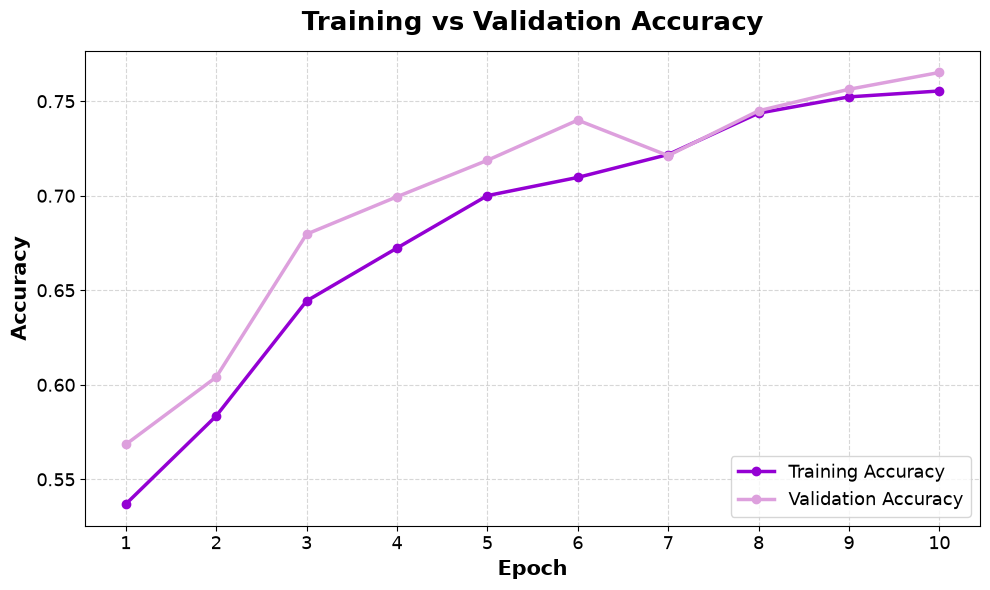

In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    dog_cat_model.history["accuracy"],
    label="Training Accuracy",
    color="darkviolet",
    linewidth=2.5,
    marker="o",
    markersize=6
)

plt.plot(
    dog_cat_model.history["val_accuracy"],
    label="Validation Accuracy",
    color="plum",
    linewidth=2.5,
    marker="o",
    markersize=6
)

plt.xlabel("Epoch", fontsize=15, fontweight="bold")
plt.ylabel("Accuracy", fontsize=15, fontweight="bold")

plt.title(
    "Training vs Validation Accuracy",
    fontsize=19,
    fontweight="bold",
    pad=15
)

plt.xticks(
    ticks=range(10),
    labels=range(1, 11),
    fontsize=13
)

plt.yticks(fontsize=13)

plt.legend(
    fontsize=13,
    loc="lower right"
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

## Training vs Validation Loss

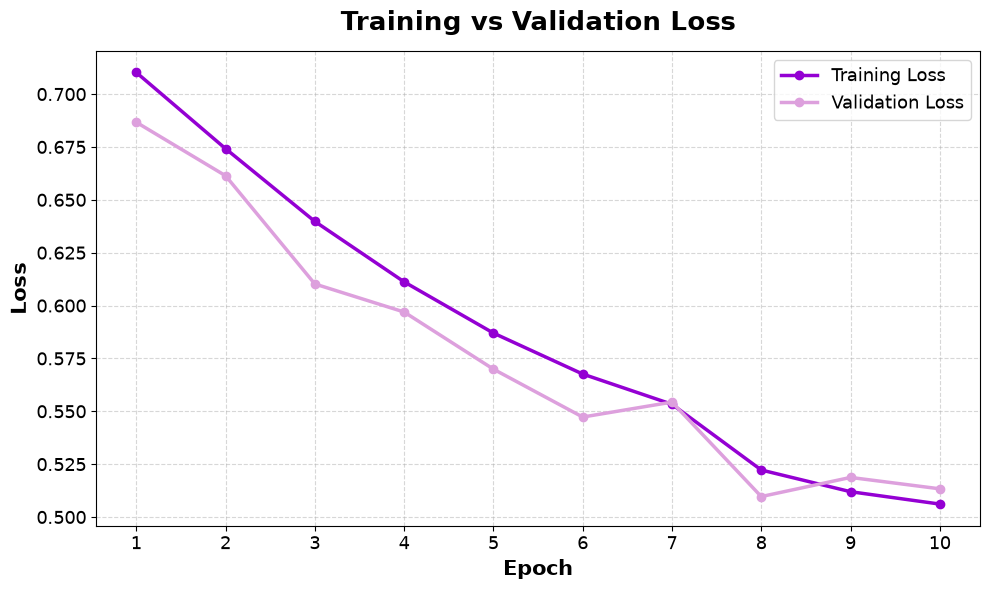

In [20]:
plt.figure(figsize=(10, 6))

plt.plot(
    dog_cat_model.history["loss"],
    label="Training Loss",
    color="darkviolet",
    linewidth=2.5,
    marker="o",
    markersize=6
)

plt.plot(
    dog_cat_model.history["val_loss"],
    label="Validation Loss",
    color="plum",
    linewidth=2.5,
    marker="o",
    markersize=6
)

plt.xlabel("Epoch", fontsize=15, fontweight="bold")
plt.ylabel("Loss", fontsize=15, fontweight="bold")

plt.title(
    "Training vs Validation Loss",
    fontsize=19,
    fontweight="bold",
    pad=15
)

plt.xticks(
    ticks=range(10),
    labels=range(1, 11),
    fontsize=13
)

plt.yticks(fontsize=13)

plt.legend(
    fontsize=13,
    loc="upper right"
)

plt.grid(
    True,
    linestyle="--",
    alpha=0.5
)

plt.tight_layout()
plt.show()

# Now let's Evaluate the CNN Model

In [21]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 11s 165ms/step - accuracy: 0.7652 - loss: 0.5133
Test Loss: 0.5133
Test Accuracy: 0.7652


#### That means  CNN correctly classified about 76.5% of  test images.

# Confusion Matrix
### First, we need to get the model's predictions for every image in test_dataset

In [23]:
y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((predictions > 0.5).astype(int).flatten())


# Creating Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[848 163]
 [312 700]]


## let's Visualize the confusion matrix

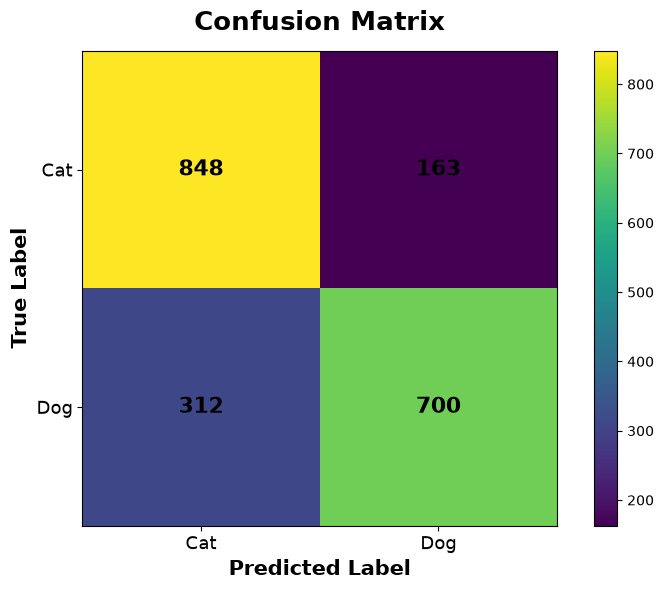

In [24]:
plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.title(
    "Confusion Matrix",
    fontsize=19,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Predicted Label",
    fontsize=15,
    fontweight="bold"
)

plt.ylabel(
    "True Label",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(
    ticks=[0, 1],
    labels=["Cat", "Dog"],
    fontsize=13
)

plt.yticks(
    ticks=[0, 1],
    labels=["Cat", "Dog"],
    fontsize=13
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold"
        )

plt.colorbar()

plt.tight_layout()
plt.show()

## Understanding the Confusion Matrix

A confusion matrix shows us **how the model's predictions compare with the actual classes**.

For our Dog vs Cat classification:

|                | Predicted Cat | Predicted Dog |
| -------------- | ------------: | ------------: |
| **Actual Cat** |   Correct Cat |     Cat → Dog |
| **Actual Dog** |     Dog → Cat |   Correct Dog |

### How to read it

```text
                    Predicted
                  Cat       Dog
               ┌────────┬────────┐
Actual Cat     │   ✓    │   ✗    │
               ├────────┼────────┤
Actual Dog     │   ✗    │   ✓    │
               └────────┴────────┘
```

* **Actual Cat → Predicted Cat:** The model correctly identified a cat.
* **Actual Cat → Predicted Dog:** The model incorrectly identified a cat as a dog.
* **Actual Dog → Predicted Cat:** The model incorrectly identified a dog as a cat.
* **Actual Dog → Predicted Dog:** The model correctly identified a dog.

The **diagonal cells** represent correct predictions, while the **off-diagonal cells** represent incorrect predictions.

Therefore, the confusion matrix helps us understand **what kind of mistakes our CNN is making**, rather than looking only at its overall accuracy.


# Classification Report

In [25]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=["Cat", "Dog"]
    )
)

              precision    recall  f1-score   support

         Cat       0.73      0.84      0.78      1011
         Dog       0.81      0.69      0.75      1012

    accuracy                           0.77      2023
   macro avg       0.77      0.77      0.76      2023
weighted avg       0.77      0.77      0.76      2023



## Classification Report

The classification report provides detailed information about how well the CNN performs for each class.

* **Precision:** How often the model is correct when it predicts a class.
* **Recall:** How many actual samples of a class the model correctly identifies.
* **F1-score:** A combined measure of precision and recall.
* **Support:** The number of actual samples belonging to each class.

### Our Model

| Class | Precision | Recall | F1-score | Support |
| ----- | --------: | -----: | -------: | ------: |
| Cat   |      0.73 |   0.84 |     0.78 |    1011 |
| Dog   |      0.81 |   0.69 |     0.75 |    1012 |

Overall, the model achieved **77% accuracy** on **2,023 test images**.

The model has **higher Cat recall (84%)**, meaning it finds more actual cats, while it has **higher Dog precision (81%)**, meaning its Dog predictions are more reliable.


# Let's Test for  Image

In [42]:
import random
from pathlib import Path
from tensorflow.keras.utils import load_img, img_to_array

# Test dataset path
test_dir = Path("../data/raw/test_set")

# Get all images
image_paths = list(test_dir.glob("cats/*")) + list(test_dir.glob("dogs/*"))

# Select a random image
image_path = random.choice(image_paths)

print("Selected image:", image_path)

Selected image: ..\data\raw\test_set\cats\cat.4107.jpg


###  Normalize image , Add Dimension and Predict the model

In [43]:
image = load_img(
    image_path,
    target_size=(256, 256)
)

image_array = img_to_array(image)
image_array = image_array / 255.0
image_array = np.expand_dims(image_array, axis=0)

prediction = model.predict(image_array, verbose=0)

## Testing with Visualization

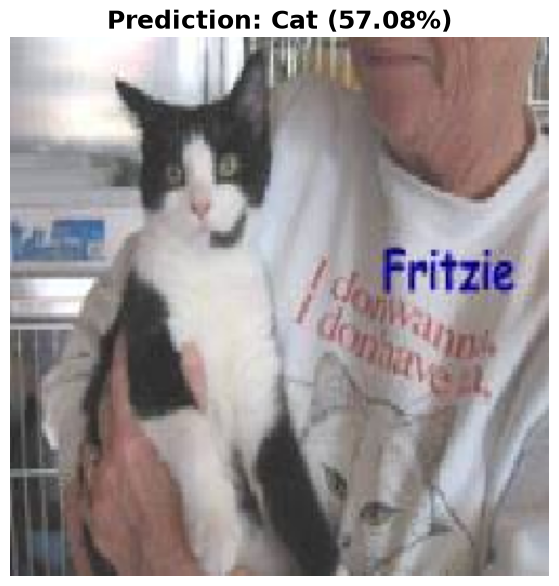

In [44]:
plt.figure(figsize=(7, 7))

plt.imshow(image)

# Convert prediction into class
if prediction[0][0] < 0.5:
    predicted_class = "Cat"
    confidence = (1 - prediction[0][0]) * 100
else:
    predicted_class = "Dog"
    confidence = prediction[0][0] * 100

plt.title(
    f"Prediction: {predicted_class} ({confidence:.2f}%)",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")
plt.show()

# Let's Save the model

In [45]:
model.save("../models/dog_cat_classifier.keras")

## Verifying the saved 

In [46]:
from pathlib import Path

model_path = Path("../models/dog_cat_classifier.keras")

print("Model saved:", model_path.exists())

Model saved: True


## Load the model and use for prediction

In [51]:
loaded_model = keras.models.load_model(
    "../models/dog_cat_classifier.keras"
)

print("Model loaded successfully!")


Model loaded successfully!


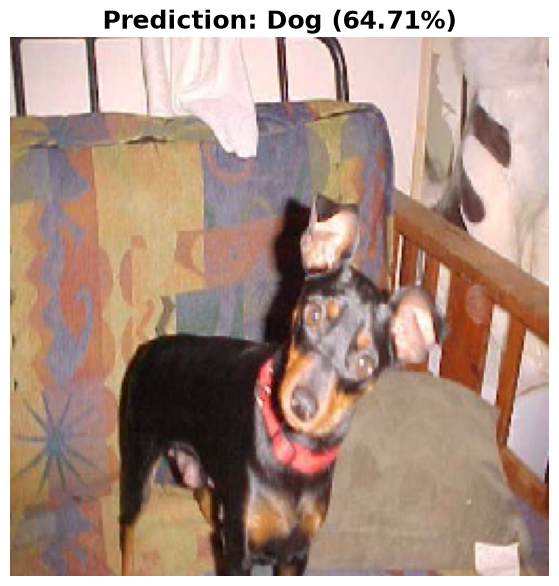

In [57]:
import random
from pathlib import Path

# Test dataset path
test_dir = Path("../data/raw/test_set")

# Get all images
image_paths = list(test_dir.glob("cats/*")) + list(test_dir.glob("dogs/*"))

# Select a random image
image_path = random.choice(image_paths)

# Load and resize
image = load_img(
    image_path,
    target_size=(256, 256)
)

# Convert to array
image_array = img_to_array(image)

# Normalize
image_array = image_array / 255.0

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# Predict using saved model
prediction = loaded_model.predict(image_array, verbose=0)

# Determine prediction
if prediction[0][0] < 0.5:
    predicted_class = "Cat"
    confidence = (1 - prediction[0][0]) * 100
else:
    predicted_class = "Dog"
    confidence = prediction[0][0] * 100

# Display
plt.figure(figsize=(7, 7))
plt.imshow(image)

plt.title(
    f"Prediction: {predicted_class} ({confidence:.2f}%)",
    fontsize=18,
    fontweight="bold"
)

plt.axis("off")
plt.show()
